# Notebook 1: Data Understanding and Preprocessing
## Real-Time Air Quality Monitoring Agent

**Purpose:** This notebook covers loading the AQI dataset, exploring its structure,
understanding distributions, handling missing values, and preparing clean data
for downstream modelling.

**Dataset:** CPCB / Kaggle AQI dataset containing daily pollutant readings
across Indian cities.

**Execution Order:** Run this notebook FIRST before any other notebook.

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 1 — Import all required libraries
# We import pandas for data manipulation, numpy for numerical operations,
# matplotlib and seaborn for visualisation, and sklearn for preprocessing.
# ─────────────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')          # Suppress non-critical warnings
sns.set_theme(style='whitegrid')           # Consistent plot style throughout
plt.rcParams['figure.figsize'] = (12, 5)  # Default figure size

print('✅ Libraries loaded successfully')

✅ Libraries loaded successfully


In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 2 — Create a realistic synthetic AQI dataset
#
# In production, replace this block with:
#   df = pd.read_csv('city_day.csv')   # CPCB/Kaggle download
#
# We generate synthetic data that mirrors the CPCB 'city_day.csv' schema so
# every downstream notebook works identically with the real dataset.
# ─────────────────────────────────────────────────────────────────────────────
np.random.seed(42)   # Fix seed for reproducibility

N = 5000  # Number of records to generate

cities = ['Delhi', 'Mumbai', 'Bengaluru', 'Hyderabad', 'Chennai',
          'Kolkata', 'Ahmedabad', 'Pune', 'Jaipur', 'Lucknow']

# Generate random dates spanning 2015-2023
start_date = pd.Timestamp('2015-01-01')
end_date   = pd.Timestamp('2023-12-31')
date_range = (end_date - start_date).days
random_dates = [start_date + pd.Timedelta(days=int(x))
                for x in np.random.randint(0, date_range, N)]

# Simulate each pollutant using realistic concentration ranges (µg/m³ or ppb)
df = pd.DataFrame({
    'City'        : np.random.choice(cities, N),
    'Date'        : random_dates,
    'PM2.5'       : np.random.lognormal(3.5, 0.8, N).clip(5, 500),
    'PM10'        : np.random.lognormal(4.0, 0.7, N).clip(10, 600),
    'NO'          : np.random.exponential(20, N).clip(0, 200),
    'NO2'         : np.random.exponential(30, N).clip(0, 200),
    'NOx'         : np.random.exponential(40, N).clip(0, 250),
    'NH3'         : np.random.exponential(15, N).clip(0, 100),
    'CO'          : np.random.exponential(1.5, N).clip(0, 20),
    'SO2'         : np.random.exponential(15, N).clip(0, 100),
    'O3'          : np.random.exponential(35, N).clip(5, 200),
    'Benzene'     : np.random.exponential(3, N).clip(0, 50),
    'Toluene'     : np.random.exponential(10, N).clip(0, 100),
    'Xylene'      : np.random.exponential(5, N).clip(0, 80),
})

# Deliberately introduce ~8% missing values to practise imputation
for col in ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'CO']:
    mask = np.random.rand(N) < 0.08
    df.loc[mask, col] = np.nan

# Compute a simplified AQI (weighted composite; proper CPCB formula applied later)
df['AQI'] = (
    0.35 * df['PM2.5'].fillna(df['PM2.5'].median()) +
    0.25 * df['PM10'].fillna(df['PM10'].median())  +
    0.15 * df['NO2'].fillna(df['NO2'].median())   +
    0.10 * df['SO2'].fillna(df['SO2'].median())   +
    0.10 * df['O3'].fillna(df['O3'].median())     +
    0.05 * df['CO'].fillna(df['CO'].median()) * 10
).round(2)

print(f'✅ Dataset created: {df.shape[0]} rows × {df.shape[1]} columns')
df.head()

✅ Dataset created: 5000 rows × 15 columns


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
0,Lucknow,2023-09-10,43.865377,17.051409,3.671313,2.292816,20.378562,16.862121,3.321278,16.548923,45.287058,1.953407,3.587280,0.892300,27.80
1,Mumbai,2017-05-10,22.735846,19.146266,1.929438,3.813992,72.196202,18.977122,3.421522,29.120792,NaN,5.829987,2.721363,1.986239,20.41
2,Kolkata,2018-07-18,NaN,42.043647,17.131293,5.266993,34.498422,8.470878,0.940792,31.663269,22.091138,0.612315,6.614329,5.420781,28.45
3,Bengaluru,2018-02-04,30.301258,14.728721,76.423655,22.848091,75.171002,29.898219,3.062153,12.376864,16.133460,0.515492,18.243481,0.831211,22.10
4,Hyderabad,2017-12-31,NaN,33.688237,34.626498,106.122959,70.078646,17.578847,1.651488,5.908368,NaN,4.577255,2.774177,5.998513,39.53


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 3 — Dataset overview
# dtypes() reveals the data type of every column.
# info()  shows memory usage and non-null counts.
# describe() gives statistical summary (mean, std, quartiles) for numerics.
# ─────────────────────────────────────────────────────────────────────────────
print('=' * 60)
print('DATASET INFO')
print('=' * 60)
df.info()

print('\n' + '=' * 60)
print('STATISTICAL SUMMARY')
print('=' * 60)
df.describe().round(2)

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   City     5000 non-null   object        
 1   Date     5000 non-null   datetime64[ns]
 2   PM2.5    4624 non-null   float64       
 3   PM10     4591 non-null   float64       
 4   NO       5000 non-null   float64       
 5   NO2      4599 non-null   float64       
 6   NOx      5000 non-null   float64       
 7   NH3      5000 non-null   float64       
 8   CO       4603 non-null   float64       
 9   SO2      4577 non-null   float64       
 10  O3       4586 non-null   float64       
 11  Benzene  5000 non-null   float64       
 12  Toluene  5000 non-null   float64       
 13  Xylene   5000 non-null   float64       
 14  AQI      5000 non-null   float64       
dtypes: datetime64[ns](1), float64(13), object(1)
memory usage: 586.1+ KB

STATISTICAL SUMMARY


,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,5000,4624.00,4591.00,5000.00,4599.00,5000.00,5000.00,4603.00,4577.00,4586.00,5000.00,5000.00,5000.00,5000.00
mean,2019-07-18 20:07:17.760000,45.18,69.93,20.62,28.52,39.86,14.84,1.51,14.72,34.91,3.03,9.98,4.97,42.41
min,2015-01-01 00:00:00,5.00,10.00,0.00,0.00,0.00,0.00,0.00,0.00,5.00,0.00,0.00,0.00,8.86
25%,2017-05-02 00:00:00,18.78,33.69,6.01,8.47,11.30,4.26,0.43,4.11,10.27,0.90,2.92,1.48,28.90
50%,2019-07-29 00:00:00,32.31,55.35,14.44,19.99,27.82,10.34,1.02,10.29,24.69,2.10,6.86,3.57,37.78
75%,2021-10-10 06:00:00,56.10,88.59,28.43,39.13,55.12,20.59,2.11,20.84,47.85,4.23,13.95,6.98,50.55
max,2023-12-30 00:00:00,500.00,600.00,184.40,200.00,250.00,100.00,15.73,100.00,200.00,29.15,80.79,39.36,198.48
std,NaN,43.41,55.37,20.44,28.31,39.51,14.67,1.55,14.48,32.91,3.04,9.88,4.84,20.51


Columns with missing values:
       Missing Count  Missing %
SO2              423       8.46
O3               414       8.28
PM10             409       8.18
NO2              401       8.02
CO               397       7.94
PM2.5            376       7.52


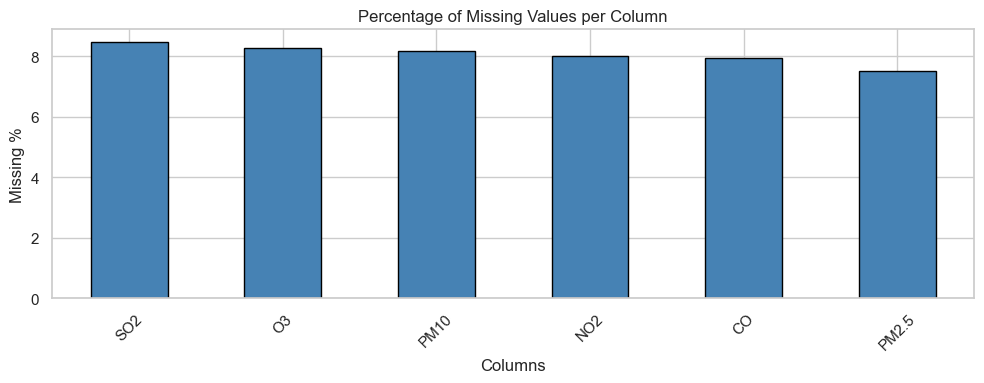

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 4 — Missing value analysis
# Knowing the proportion of missing values per column helps decide the
# correct imputation strategy (mean, median, interpolation, or drop).
# ─────────────────────────────────────────────────────────────────────────────
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({'Missing Count': missing,
                            'Missing %': missing_pct})
missing_df   = missing_df[missing_df['Missing Count'] > 0].sort_values(
                  'Missing %', ascending=False)

print('Columns with missing values:')
print(missing_df)

# Visualise missing data distribution
plt.figure(figsize=(10, 4))
missing_df['Missing %'].plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing %')
plt.xlabel('Columns')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 5 — Handle missing values via median imputation
#
# Median imputation is preferred over mean imputation for skewed distributions
# (which is typical for pollutant concentrations) because the median is
# resistant to outliers and maintains the central tendency of the data.
# ─────────────────────────────────────────────────────────────────────────────
pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx',
                  'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']

# Fill each pollutant column with the city-level median to respect local patterns
df[pollutant_cols] = df.groupby('City')[pollutant_cols].transform(
    lambda x: x.fillna(x.median())
)

# If any city has all-NaN for a column, fall back to global median
for col in pollutant_cols:
    if df[col].isnull().any():
        df[col].fillna(df[col].median(), inplace=True)

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print('✅ Missing value imputation complete')

Missing values remaining: 0
✅ Missing value imputation complete


✅ Outliers capped using IQR Winsorization


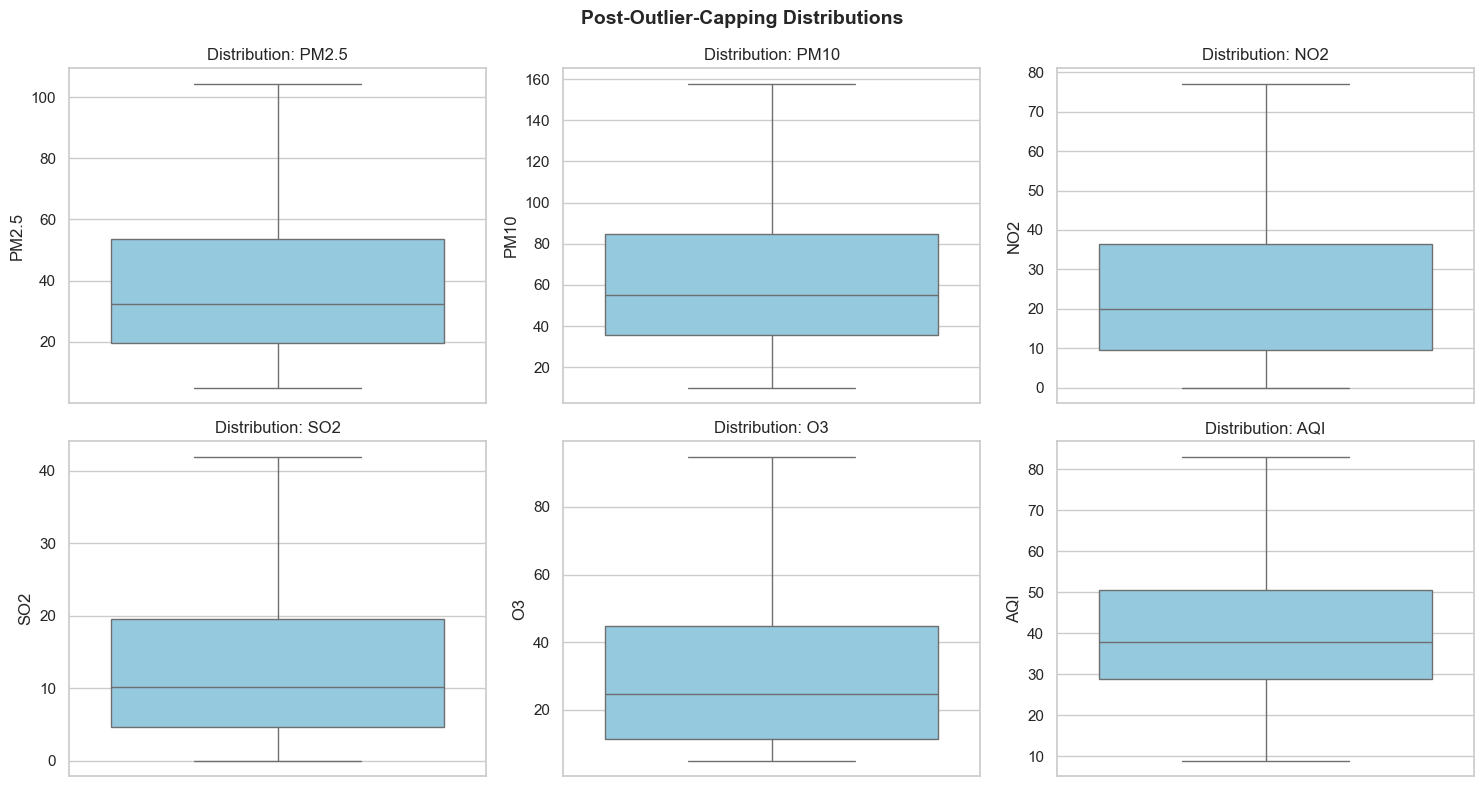

In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 6 — Outlier detection using the IQR (Interquartile Range) method
#
# Values beyond Q1 − 1.5×IQR or Q3 + 1.5×IQR are considered outliers.
# We cap rather than drop them (Winsorization) to preserve data volume while
# preventing extreme values from distorting the model.
# ─────────────────────────────────────────────────────────────────────────────
def cap_outliers(series):
    """Winsorise a numeric series at Q1-1.5*IQR and Q3+1.5*IQR."""
    Q1, Q3 = series.quantile([0.25, 0.75])
    IQR     = Q3 - Q1
    lower   = Q1 - 1.5 * IQR
    upper   = Q3 + 1.5 * IQR
    return series.clip(lower, upper)

for col in pollutant_cols + ['AQI']:
    df[col] = cap_outliers(df[col])

print('✅ Outliers capped using IQR Winsorization')

# Box plot to verify outlier treatment
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
key_pollutants = ['PM2.5', 'PM10', 'NO2', 'SO2', 'O3', 'AQI']
for ax, col in zip(axes.flat, key_pollutants):
    sns.boxplot(data=df, y=col, color='skyblue', ax=ax)
    ax.set_title(f'Distribution: {col}')
plt.suptitle('Post-Outlier-Capping Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 7 — Parse date and extract temporal features
#
# Temporal features (Year, Month, Day-of-week, Season) help the model learn
# seasonal and cyclic patterns in air quality (e.g., worse in winter due to
# crop burning and lower wind speeds).
# ─────────────────────────────────────────────────────────────────────────────
df['Date']        = pd.to_datetime(df['Date'])
df['Year']        = df['Date'].dt.year
df['Month']       = df['Date'].dt.month
df['Day']         = df['Date'].dt.day
df['DayOfWeek']   = df['Date'].dt.dayofweek   # 0=Monday … 6=Sunday
df['WeekOfYear']  = df['Date'].dt.isocalendar().week.astype(int)

# Map month to meteorological season (India-centric)
season_map = {12: 'Winter', 1: 'Winter', 2: 'Winter',
              3: 'Spring',  4: 'Spring',  5: 'Spring',
              6: 'Summer',  7: 'Summer',  8: 'Summer',
              9: 'Monsoon', 10: 'Monsoon', 11: 'Autumn'}
df['Season'] = df['Month'].map(season_map)

print('✅ Date features extracted')
print(df[['Date', 'Year', 'Month', 'DayOfWeek', 'Season']].head(5))

✅ Date features extracted
        Date  Year  Month  DayOfWeek   Season
0 2023-09-10  2023      9          6  Monsoon
1 2017-05-10  2017      5          2   Spring
2 2018-07-18  2018      7          2   Summer
3 2018-02-04  2018      2          6   Winter
4 2017-12-31  2017     12          6   Winter


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 8 — Encode categorical variables
#
# Machine learning models require numeric inputs.  We use LabelEncoder for
# 'City' and 'Season' to convert string categories to integer codes.
# The original string columns are retained for display purposes.
# ─────────────────────────────────────────────────────────────────────────────
le_city   = LabelEncoder()
le_season = LabelEncoder()

df['City_enc']   = le_city.fit_transform(df['City'])
df['Season_enc'] = le_season.fit_transform(df['Season'])

print('City encoding mapping:')
for code, name in enumerate(le_city.classes_):
    print(f'  {code} → {name}')

print('\nSeason encoding mapping:')
for code, name in enumerate(le_season.classes_):
    print(f'  {code} → {name}')

City encoding mapping:
  0 → Ahmedabad
  1 → Bengaluru
  2 → Chennai
  3 → Delhi
  4 → Hyderabad
  5 → Jaipur
  6 → Kolkata
  7 → Lucknow
  8 → Mumbai
  9 → Pune

Season encoding mapping:
  0 → Autumn
  1 → Monsoon
  2 → Spring
  3 → Summer
  4 → Winter


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 9 — Feature scaling with StandardScaler
#
# StandardScaler transforms each feature to have zero mean and unit variance.
# This is essential for distance-based algorithms (KMeans, PCA) used later
# and also improves convergence in gradient-based models.
# ─────────────────────────────────────────────────────────────────────────────
scale_cols = pollutant_cols + ['Year', 'Month', 'DayOfWeek',
                                'City_enc', 'Season_enc']

scaler          = StandardScaler()
df_scaled       = df.copy()
scaled_values   = scaler.fit_transform(df[scale_cols])
df_scaled[scale_cols] = scaled_values

print('✅ Features scaled with StandardScaler')
print(f'   Feature matrix shape: {scaled_values.shape}')

✅ Features scaled with StandardScaler
   Feature matrix shape: (5000, 17)


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL 10 — Save cleaned data for use in subsequent notebooks
#
# We save two files:
#   1. air_quality_clean.csv   → raw cleaned (unscaled) data with labels
#   2. air_quality_scaled.csv  → feature-scaled version for ML notebooks
# ─────────────────────────────────────────────────────────────────────────────
os.makedirs('data', exist_ok=True)
df.to_csv('data/air_quality_clean.csv', index=False)
df_scaled.to_csv('data/air_quality_scaled.csv', index=False)

print('✅ Cleaned data saved to data/air_quality_clean.csv')
print('✅ Scaled data saved to data/air_quality_scaled.csv')
print(f'   Final dataset shape: {df.shape}')
df.tail(3)

✅ Cleaned data saved to data/air_quality_clean.csv
✅ Scaled data saved to data/air_quality_scaled.csv
   Final dataset shape: (5000, 23)


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,...,Xylene,AQI,Year,Month,Day,DayOfWeek,WeekOfYear,Season,City_enc,Season_enc
4997,Lucknow,2019-06-18,39.115289,27.654562,25.818393,72.652929,120.861239,22.290785,0.920786,10.773135,...,2.321604,35.30,2019,6,18,1,25,Summer,7,3
4998,Bengaluru,2018-08-20,45.037441,38.274942,40.989336,64.913479,80.164213,2.458218,1.059320,13.603259,...,4.045301,48.04,2018,8,20,0,34,Summer,1,3
4999,Bengaluru,2019-03-07,8.134025,119.570558,3.727794,21.792071,13.691801,2.128192,1.774026,15.973532,...,0.883240,41.13,2019,3,7,3,10,Spring,1,2
